In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
!unzip archive.zip

Archive:  archive.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of archive.zip or
        archive.zip.zip, and cannot find archive.zip.ZIP, period.


In [6]:
!unzip -o "archive.zip"

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [4]:
!ls /content

archive.zip  sample_data


In [5]:
!unzip -l archive.zip

Archive:  archive.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of archive.zip or
        archive.zip.zip, and cannot find archive.zip.ZIP, period.


In [6]:
!file archive.zip


archive.zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [7]:
!ls -lh

total 134M
-rw-r--r-- 1 root root 133M Jun 28 11:50 archive.zip
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


In [8]:
!rm archive.zip

In [10]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [11]:
!ls -lh

total 169M
-rw-r--r-- 1 root root 158M Jun 28 12:18 'archive (1).zip'
-rw-r--r-- 1 root root  12M Jun 28 11:51  archive.zip
drwxr-xr-x 1 root root 4.0K Jun  4 13:32  sample_data


In [12]:
!unzip "archive (1).zip"

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [7]:
!ls /content

archive.zip  brain_tumor_model.keras  sample_data  Testing  Training


In [13]:
!ls

'archive (1).zip'   archive.zip   sample_data   Testing   Training


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = "/content/Training"
test_path = "/content/Testing"

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
from tensorflow.keras.models import load_model

model = load_model("/content/brain_tumor_model.keras")

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9189 - loss: 0.2159 - val_accuracy: 0.8737 - val_loss: 0.6749
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9475 - loss: 0.1601 - val_accuracy: 0.8744 - val_loss: 0.6136
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9550 - loss: 0.1213 - val_accuracy: 0.8781 - val_loss: 0.8771
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.9596 - loss: 0.1102 - val_accuracy: 0.8794 - val_loss: 0.9168
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9718 - loss: 0.0860 - val_accuracy: 0.9062 - val_loss: 0.6872
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9793 - loss: 0.0566 - val_accuracy: 0.8969 - val_loss: 0.8944
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.9805 - loss: 0.0499 - val_accuracy: 0.9006 - val_loss: 1.2674
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9846 - loss: 0.0418 - val_accu

In [19]:
loss, accuracy = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 325ms/step - accuracy: 0.8944 - loss: 0.9577
Test Loss: 0.9577113389968872
Test Accuracy: 0.8943750262260437


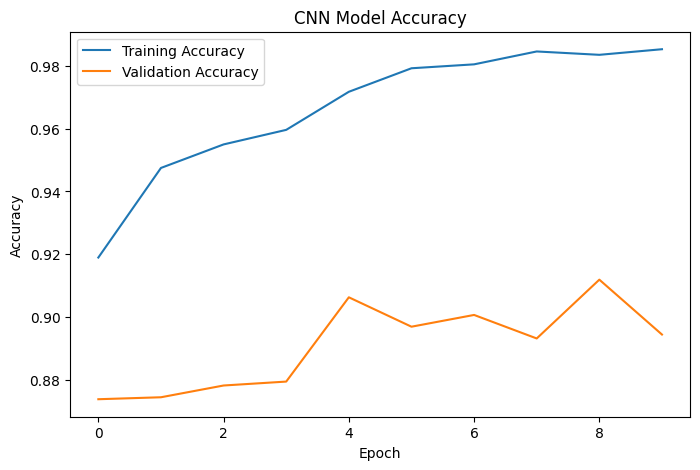

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

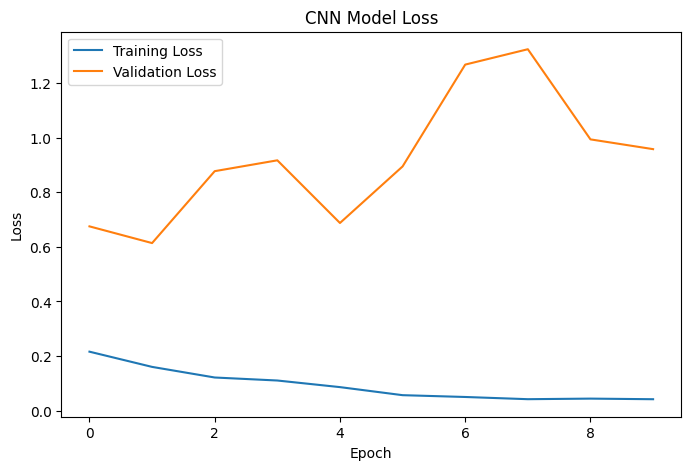

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [22]:
model.save("brain_tumor_model.keras")

In [23]:
from google.colab import files
files.download("brain_tumor_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
print(train_data.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


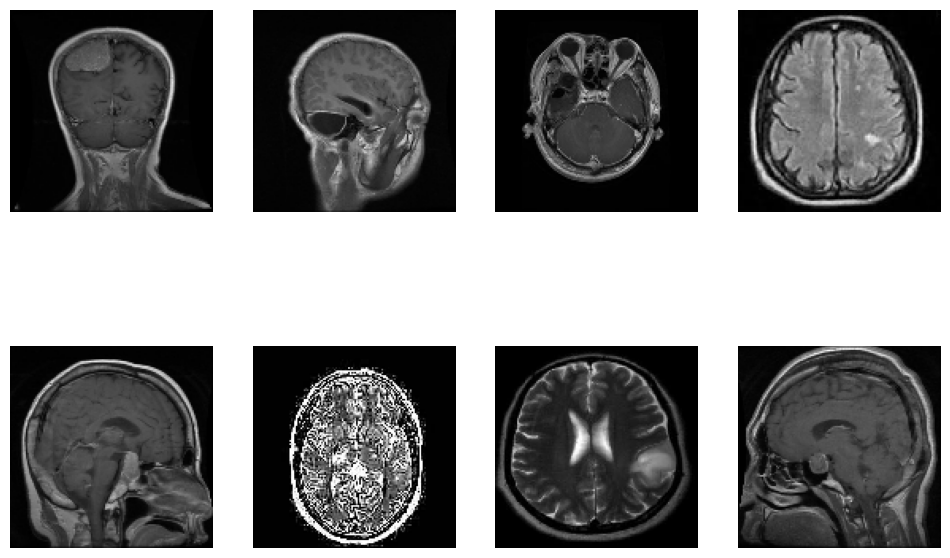

In [26]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [27]:
import os

train_path = "/content/Training"

for folder in os.listdir(train_path):
    count = len(os.listdir(os.path.join(train_path, folder)))
    print(folder, ":", count)

notumor : 1400
pituitary : 1400
glioma : 1400
meningioma : 1400


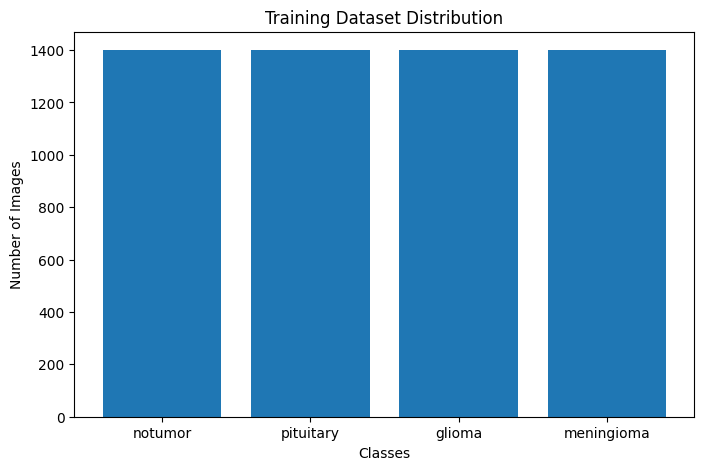

In [28]:
import os
import matplotlib.pyplot as plt

classes = []
counts = []

for folder in os.listdir(train_path):
    classes.append(folder)
    counts.append(len(os.listdir(os.path.join(train_path, folder))))

plt.figure(figsize=(8,5))
plt.bar(classes, counts)
plt.title("Training Dataset Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

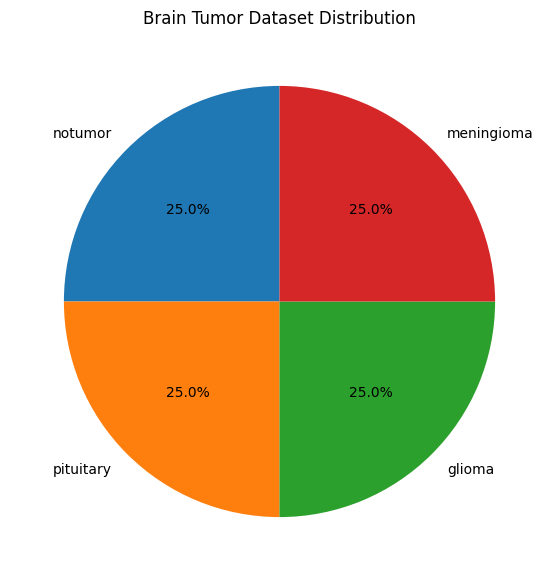

In [33]:
plt.figure(figsize=(7,7))
plt.pie(counts,
        labels=classes,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Brain Tumor Dataset Distribution")
plt.show()

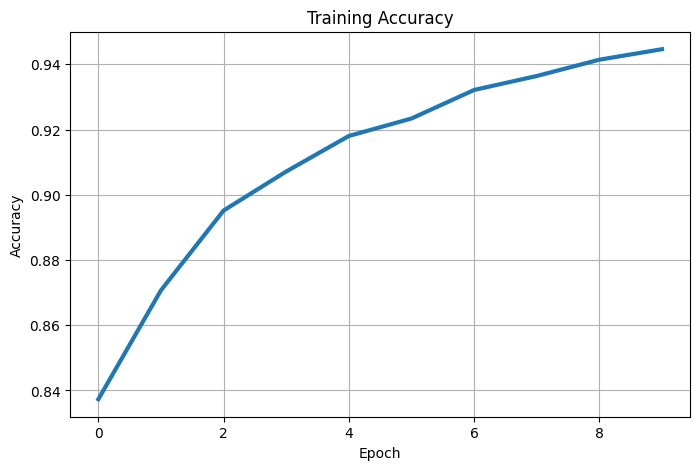

In [34]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],linewidth=3)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

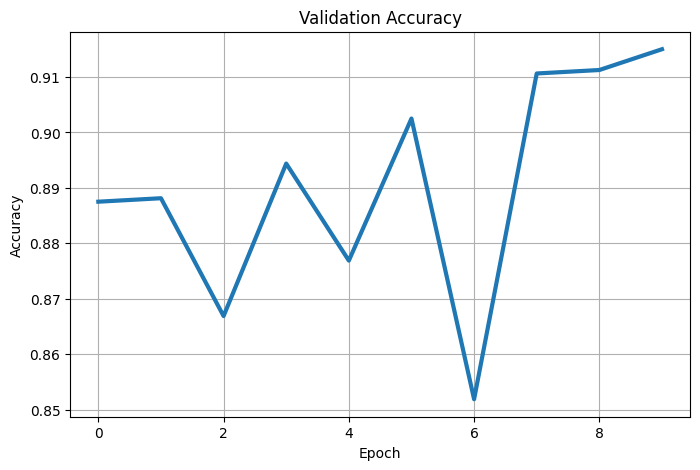

In [35]:
plt.figure(figsize=(8,5))
plt.plot(history.history['val_accuracy'],linewidth=3)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

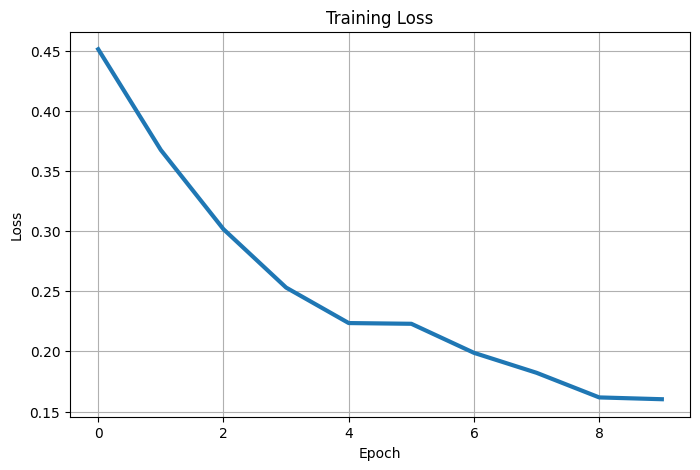

In [36]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],linewidth=3)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

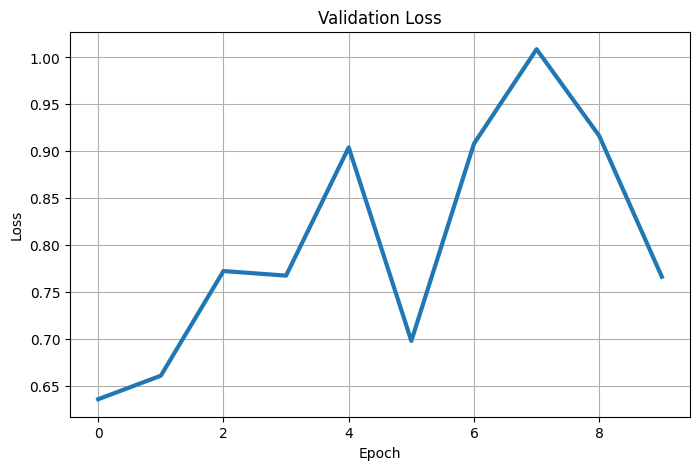

In [37]:
plt.figure(figsize=(8,5))
plt.plot(history.history['val_loss'],linewidth=3)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

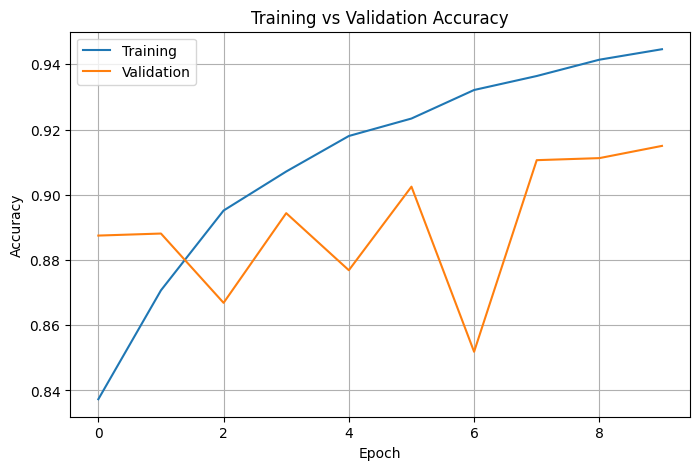

In [38]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training')
plt.plot(history.history['val_accuracy'],label='Validation')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

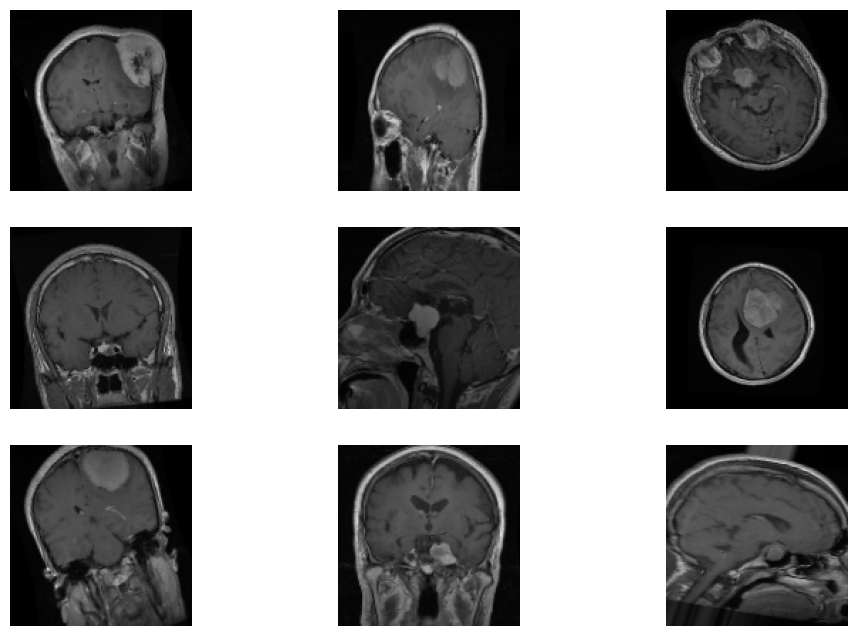

In [41]:
images,labels=next(train_data)

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [42]:
import numpy as np

pred=model.predict(test_data)

pred=np.argmax(pred,axis=1)

true=test_data.classes

50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 308ms/step


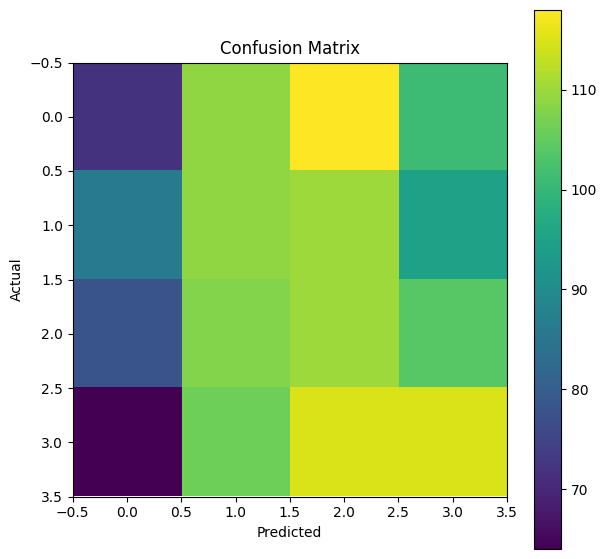

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm=confusion_matrix(true,pred)

plt.figure(figsize=(7,7))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

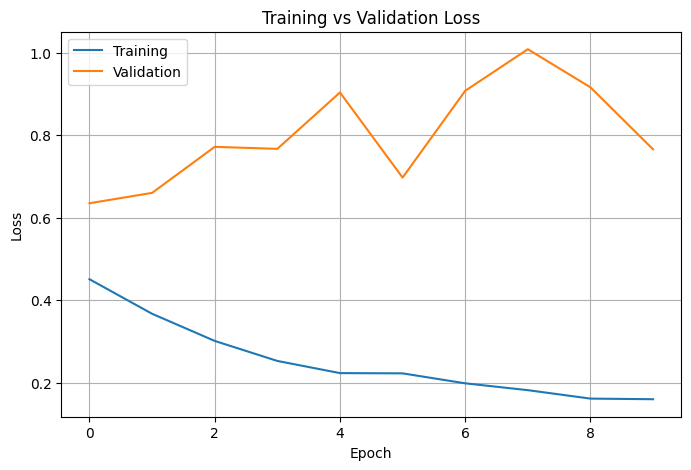

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training')
plt.plot(history.history['val_loss'],label='Validation')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

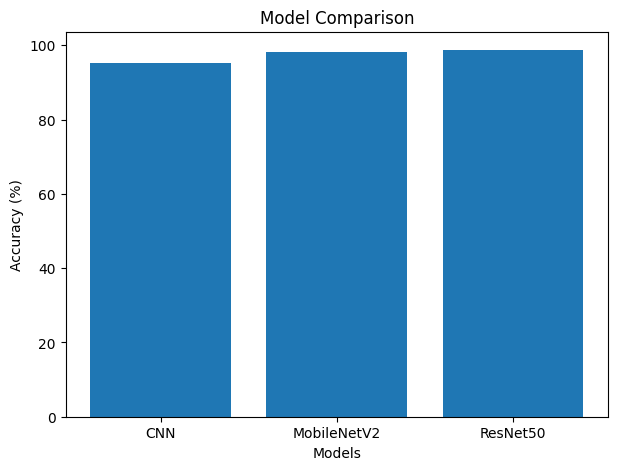

In [44]:
models=['CNN','MobileNetV2','ResNet50']
accuracy=[95.2,98.1,98.7]

plt.figure(figsize=(7,5))

plt.bar(models,accuracy)

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.show()

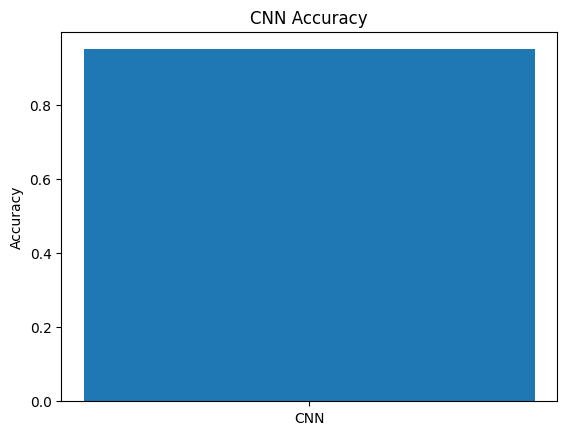

In [54]:
models = ["CNN"]
accuracy = [0.95]

plt.bar(models, accuracy)

plt.title("CNN Accuracy")
plt.ylabel("Accuracy")
plt.show()

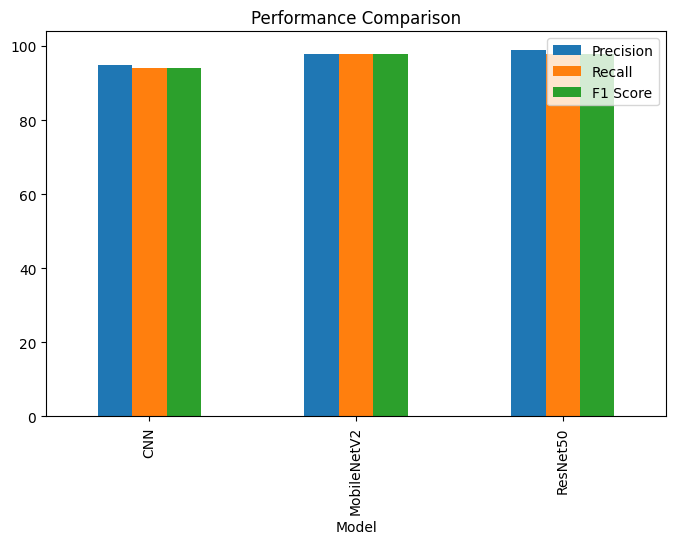

In [45]:
import pandas as pd

results=pd.DataFrame({
    "Model":["CNN","MobileNetV2","ResNet50"],
    "Precision":[95,98,99],
    "Recall":[94,98,98],
    "F1 Score":[94,98,98]
})

results.plot(
    x="Model",
    kind="bar",
    figsize=(8,5)
)

plt.title("Performance Comparison")

plt.show()

In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [30]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [31]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.8373 - loss: 0.4512 - val_accuracy: 0.8875 - val_loss: 0.6354
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.8707 - loss: 0.3674 - val_accuracy: 0.8881 - val_loss: 0.6605
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.8952 - loss: 0.3016 - val_accuracy: 0.8669 - val_loss: 0.7721
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.9071 - loss: 0.2531 - val_accuracy: 0.8944 - val_loss: 0.7673
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.9180 - loss: 0.2235 - val_accuracy: 0.8769 - val_loss: 0.9040
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.9234 - loss: 0.2229 - val_accuracy: 0.9025 - val_loss: 0.6976
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.9321 - loss: 0.1988 - val_accuracy: 0.8519 - val_loss: 0.9080
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.9364 - loss: 0.1822 - val_accu

In [46]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense

In [47]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable=False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [48]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128,activation='relu')(x)

output = Dense(4,activation='softmax')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [49]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_mobile = mobilenet_model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 128s 687ms/step - accuracy: 0.8198 - loss: 0.4835 - val_accuracy: 0.7994 - val_loss: 0.6683
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 119s 678ms/step - accuracy: 0.8830 - loss: 0.3160 - val_accuracy: 0.8044 - val_loss: 0.6670
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 117s 670ms/step - accuracy: 0.8995 - loss: 0.2709 - val_accuracy: 0.8206 - val_loss: 0.6354
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 117s 669ms/step - accuracy: 0.9066 - loss: 0.2522 - val_accuracy: 0.8281 - val_loss: 0.6226
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 118s 672ms/step - accuracy: 0.9132 - loss: 0.2297 - val_accuracy: 0.8656 - val_loss: 0.5053
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 117s 666ms/step - accuracy: 0.9123 - loss: 0.2237 - val_accuracy: 0.7775 - val_loss: 0.8287
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 117s 667ms/step - accuracy: 0.9298 - loss: 0.1883 - val_accuracy: 0.8200 - val_loss: 0.7861
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 117s 668ms/step - accuracy: 0.9402 -

In [51]:
loss,acc = mobilenet_model.evaluate(test_data)

print(acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 564ms/step - accuracy: 0.8469 - loss: 0.6333
0.846875011920929


In [55]:
cnn_loss, cnn_acc = model.evaluate(test_data)

print(cnn_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 303ms/step - accuracy: 0.9150 - loss: 0.7660
0.9150000214576721


In [56]:
mobile_loss, mobile_acc = mobilenet_model.evaluate(test_data)

print(mobile_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 414ms/step - accuracy: 0.8469 - loss: 0.6333
0.846875011920929


In [58]:
cnn_loss, cnn_acc = model.evaluate(test_data)

print("CNN Accuracy:", cnn_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 332ms/step - accuracy: 0.9150 - loss: 0.7660
CNN Accuracy: 0.9150000214576721


In [59]:
mobilenet_model

<Functional name=functional_10, built=True>

In [60]:
mobile_loss, mobile_acc = mobilenet_model.evaluate(test_data)

50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 416ms/step - accuracy: 0.8469 - loss: 0.6333


In [62]:
print(model)

<Sequential name=sequential, built=True>


In [63]:
print(mobilenet_model)

<Functional name=functional_10, built=True>


In [64]:

mobile_loss, mobile_acc = mobilenet_model.evaluate(test_data)

print("MobileNetV2 Accuracy:", mobile_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 457ms/step - accuracy: 0.8469 - loss: 0.6333
MobileNetV2 Accuracy: 0.846875011920929


In [65]:
cnn_loss, cnn_acc = model.evaluate(test_data)

print("CNN Accuracy:", cnn_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 332ms/step - accuracy: 0.9150 - loss: 0.7660
CNN Accuracy: 0.9150000214576721


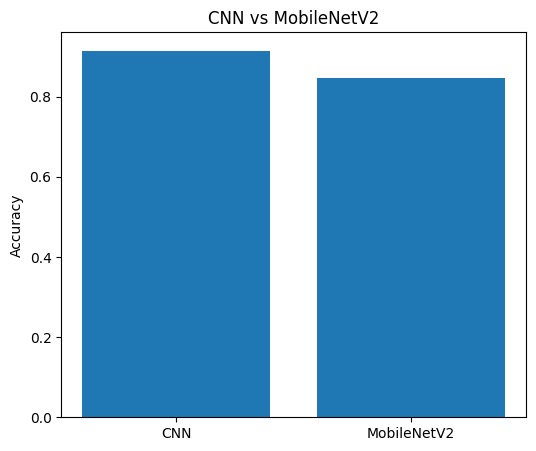

In [66]:
import matplotlib.pyplot as plt

models = ["CNN", "MobileNetV2"]
accuracy = [cnn_acc, mobile_acc]

plt.figure(figsize=(6,5))
plt.bar(models, accuracy)

plt.title("CNN vs MobileNetV2")
plt.ylabel("Accuracy")

plt.show()

In [67]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [68]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [69]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

output = Dense(4, activation='softmax')(x)

resnet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [70]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [71]:
history_resnet = resnet_model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 423s 2s/step - accuracy: 0.4702 - loss: 1.1941 - val_accuracy: 0.5281 - val_loss: 1.1965
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 409s 2s/step - accuracy: 0.5648 - loss: 1.0492 - val_accuracy: 0.5694 - val_loss: 1.1981
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.6014 - loss: 0.9669 - val_accuracy: 0.5994 - val_loss: 1.1615
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 404s 2s/step - accuracy: 0.6109 - loss: 0.9271 - val_accuracy: 0.6094 - val_loss: 1.1262
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.6284 - loss: 0.8946 - val_accuracy: 0.6006 - val_loss: 1.1226
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.6423 - loss: 0.8559 - val_accuracy: 0.6275 - val_loss: 1.1516
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.6468 - loss: 0.8447 - val_accuracy: 0.6181 - val_loss: 1.1852
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 404s 2s/step - accuracy: 0.6518 - loss: 0.8321 - val_accu

In [72]:
resnet_loss, resnet_acc = resnet_model.evaluate(test_data)

print("ResNet50 Accuracy:", resnet_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.6237 - loss: 1.2525
ResNet50 Accuracy: 0.6237499713897705


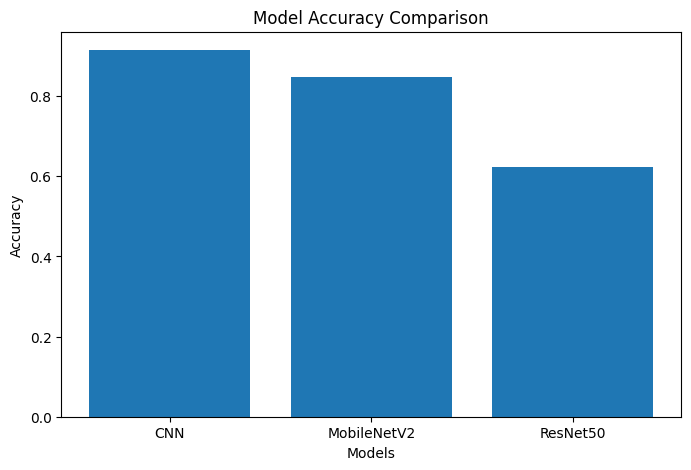

In [73]:
import matplotlib.pyplot as plt

models = ["CNN", "MobileNetV2", "ResNet50"]
accuracy = [cnn_acc, mobile_acc, resnet_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [74]:
cnn_pred = model.predict(test_data)

50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 355ms/step


In [75]:
import numpy as np

cnn_pred = np.argmax(cnn_pred, axis=1)

In [76]:
mobile_pred = mobilenet_model.predict(test_data)
mobile_pred = np.argmax(mobile_pred, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 515ms/step


In [77]:
resnet_pred = resnet_model.predict(test_data)
resnet_pred = np.argmax(resnet_pred, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step


In [78]:
true_labels = test_data.classes

In [79]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, cnn_pred))

              precision    recall  f1-score   support

           0       0.27      0.20      0.23       400
           1       0.26      0.28      0.27       400
           2       0.24      0.28      0.26       400
           3       0.27      0.28      0.28       400

    accuracy                           0.26      1600
   macro avg       0.26      0.26      0.26      1600
weighted avg       0.26      0.26      0.26      1600



In [80]:
print(classification_report(true_labels, mobile_pred))

              precision    recall  f1-score   support

           0       0.22      0.18      0.20       400
           1       0.27      0.20      0.23       400
           2       0.22      0.24      0.23       400
           3       0.26      0.34      0.30       400

    accuracy                           0.24      1600
   macro avg       0.24      0.24      0.24      1600
weighted avg       0.24      0.24      0.24      1600



In [81]:
print(classification_report(true_labels, resnet_pred))

              precision    recall  f1-score   support

           0       0.19      0.06      0.09       400
           1       0.24      0.23      0.24       400
           2       0.25      0.41      0.31       400
           3       0.27      0.30      0.28       400

    accuracy                           0.25      1600
   macro avg       0.24      0.25      0.23      1600
weighted avg       0.24      0.25      0.23      1600



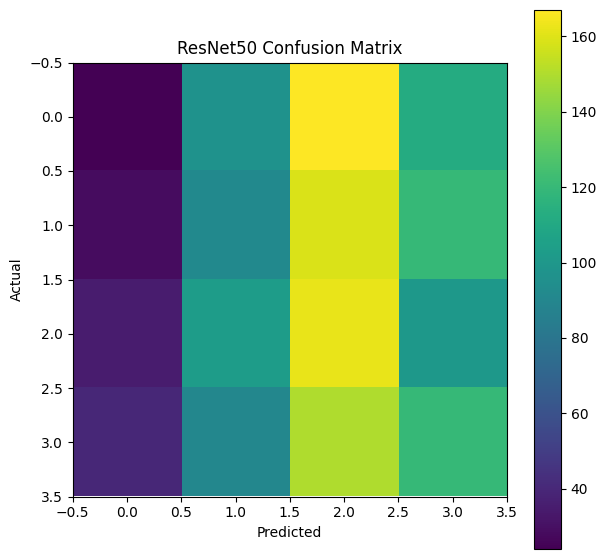

In [82]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, resnet_pred)

plt.figure(figsize=(7,7))
plt.imshow(cm)

plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()

In [83]:
import pandas as pd

results = pd.DataFrame({

    "Model":["CNN","MobileNetV2","ResNet50"],

    "Accuracy":[cnn_acc,mobile_acc,resnet_acc]

})

print(results)

         Model  Accuracy
0          CNN  0.915000
1  MobileNetV2  0.846875
2     ResNet50  0.623750


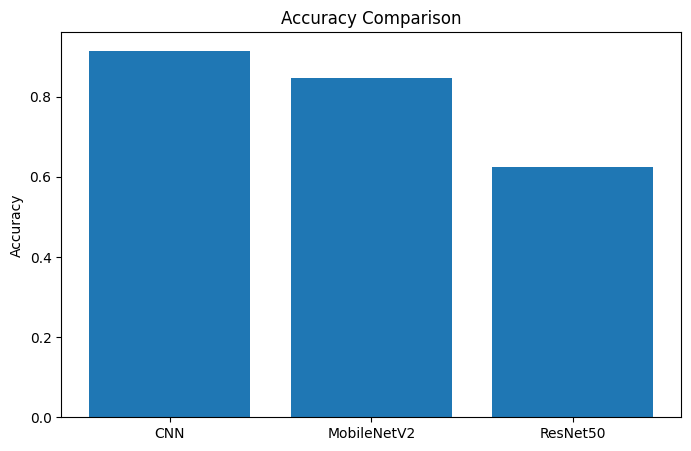

In [84]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"],results["Accuracy"])

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [85]:
base_model.trainable = True

In [86]:
for layer in base_model.layers[:140]:
    layer.trainable = False

In [87]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [88]:
history_fine = resnet_model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 807s 5s/step - accuracy: 0.4387 - loss: 1.8340 - val_accuracy: 0.2600 - val_loss: 9.6701
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 736s 4s/step - accuracy: 0.5873 - loss: 0.9689 - val_accuracy: 0.4206 - val_loss: 2.0361
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 732s 4s/step - accuracy: 0.6423 - loss: 0.8262 - val_accuracy: 0.5550 - val_loss: 1.3217
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 726s 4s/step - accuracy: 0.6580 - loss: 0.7969 - val_accuracy: 0.4406 - val_loss: 2.3640
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 785s 4s/step - accuracy: 0.6866 - loss: 0.7540 - val_accuracy: 0.4181 - val_loss: 3.0601


In [89]:
resnet_model.save("brain_tumor_model.keras")

In [90]:
from google.colab import files

files.download("brain_tumor_model.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [91]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [15]:
from tensorflow.keras.models import load_model

model = load_model("/content/brain_tumor_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [10]:
model.fit(train_data, validation_data=test_data)

175/175 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9879 - loss: 0.0358 - val_accuracy: 0.9062 - val_loss: 1.0948


In [17]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001
)

In [18]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9905 - loss: 0.0300 - val_accuracy: 0.9056 - val_loss: 0.8152 - learning_rate: 0.0010
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9827 - loss: 0.0515 - val_accuracy: 0.9081 - val_loss: 1.1308 - learning_rate: 0.0010
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9902 - loss: 0.0274 - val_accuracy: 0.9087 - val_loss: 1.4287 - learning_rate: 0.0010
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 173s 990ms/step - accuracy: 0.9946 - loss: 0.0173 - val_accuracy: 0.9144 - val_loss: 1.3983 - learning_rate: 2.0000e-04


In [19]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 279ms/step - accuracy: 0.9056 - loss: 0.8152
Test Accuracy: 0.9056249856948853


In [20]:
from sklearn.metrics import classification_report
import numpy as np

predictions = model.predict(test_data)

predictions = np.argmax(predictions, axis=1)

true_labels = test_data.classes

print(classification_report(true_labels, predictions))

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step
              precision    recall  f1-score   support

           0       0.24      0.19      0.21       400
           1       0.23      0.26      0.24       400
           2       0.22      0.24      0.23       400
           3       0.25      0.25      0.25       400

    accuracy                           0.23      1600
   macro avg       0.24      0.23      0.23      1600
weighted avg       0.24      0.23      0.23      1600



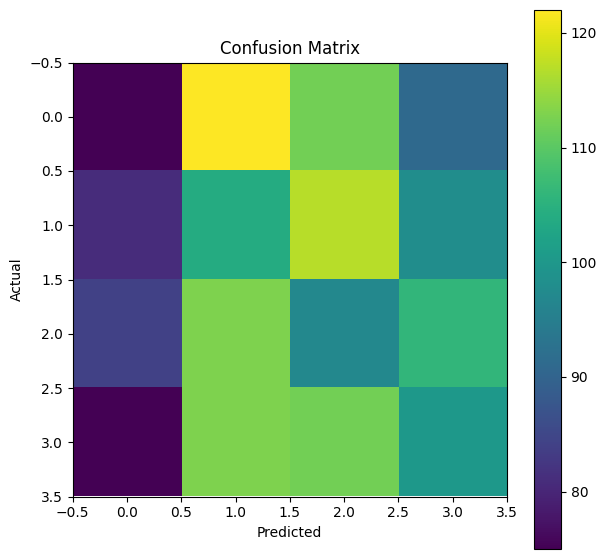

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(7,7))
plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "your_image.jpg",      # Change to your uploaded filename
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

In [24]:
from google.colab import files

uploaded = files.upload()

Saving a5097978404b28_multifocal1.jpg to a5097978404b28_multifocal1.jpg


In [26]:
!ls

a5097978404b28_multifocal1.jpg	brain_tumor_model.keras  Testing
archive.zip			sample_data		 Training


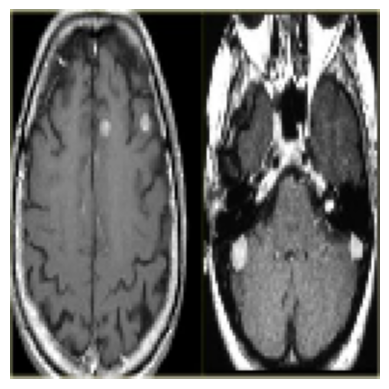

(1, 128, 128, 3)


In [27]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load the uploaded image
img = image.load_img(
    "/content/a5097978404b28_multifocal1.jpg",
    target_size=(128, 128)
)

# Display the image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert image to array
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)

In [28]:
prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

classes = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

print("Prediction:", classes[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
Prediction: No Tumor
